In [54]:
# ==========================================================
# 1. Imports
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

In [55]:
# ==========================================================
# 2. Load Dataset
# ==========================================================
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "Dataset" / "Cleaned_dataset.csv"
FINAL_PATH = PROJECT_ROOT / "Dataset" / "model_ready_dataset.csv"

df = pd.read_csv(DATA_PATH)
print("Original Shape:", df.shape)

Original Shape: (9551, 20)


In [56]:
# ==========================================================
# 3. Remove Invalid Ratings
# ==========================================================
df = df[df["Aggregate rating"] > 0].copy()
print("After removing zero ratings:", df.shape)

After removing zero ratings: (7403, 20)


In [57]:
# ==========================================================
# 4. Feature Engineering
# ==========================================================

# Cuisine count
df["Cuisine_Count"] = df["Cuisines"].apply(lambda x: len(str(x).split(", ")))

# Log transforms (handle skew)
df["Log_Votes"] = np.log1p(df["Votes"])
df["Log_Average_Cost"] = np.log1p(df["Average Cost for two"])

# Cost category
df["Cost_Category"] = df["Price range"].map({
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Premium"
})

In [58]:
# ==========================================================
# 5. Reduce Cuisine Dimensionality (Top 20 Only)
# ==========================================================

# Extract individual cuisines
cuisine_series = df["Cuisines"].str.split(", ").explode()

top_20_cuisines = cuisine_series.value_counts().head(20).index.tolist()

for cuisine in top_20_cuisines:
    df[f"Cuisine_{cuisine}"] = df["Cuisines"].apply(
        lambda x: 1 if cuisine in str(x) else 0
    )

# Drop original cuisine column
df.drop(columns=["Cuisines"], inplace=True)

In [59]:
# ==========================================================
# 6. Drop High-Cardinality & Leakage Columns
# ==========================================================

target = "Aggregate rating"

drop_columns = [
    "Restaurant ID",
    "Restaurant Name",
    "Address",
    "Locality",
    "Locality Verbose",
    "Rating color",
    "Rating text",
    "Currency",
    "Votes",                  # replaced by log
    "Average Cost for two"    # replaced by log
]

df_model = df.drop(columns=[col for col in drop_columns if col in df.columns])

print("Shape after dropping unnecessary columns:", df_model.shape)

Shape after dropping unnecessary columns: (7403, 33)


In [60]:
# ==========================================================
# 7. Prepare Features & Target
# ==========================================================

y = df_model[target]
X = df_model.drop(columns=[target])

# One-hot encode remaining low-cardinality columns
X = pd.get_dummies(X, drop_first=True)

print("Final Feature Matrix Shape:", X.shape)

Final Feature Matrix Shape: (7403, 173)


In [61]:
# ==========================================================
# 8. Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [62]:
# ==========================================================
# 9. Evaluation Function
# ==========================================================

def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} Performance")
    print("MSE :", round(mse,4))
    print("MAE :", round(mae,4))
    print("RMSE:", round(rmse,4))
    print("R2  :", round(r2,4))

    return mse, mae, rmse, r2

In [63]:
# ==========================================================
# 10. Linear Regression (Scaled)
# ==========================================================

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

mse_lr, mae_lr, rmse_lr, r2_lr = evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)


Linear Regression Performance
MSE : 0.1143
MAE : 0.2511
RMSE: 0.338
R2  : 0.6305


In [64]:
# ==========================================================
# 11. Tree-Based Models
# ==========================================================

models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse, mae, rmse, r2 = evaluate_model(name, y_test, pred)
    results.append([name, mse, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MSE", "MAE", "RMSE", "R2"]
)

results_df


Decision Tree Performance
MSE : 0.2226
MAE : 0.3411
RMSE: 0.4718
R2  : 0.2802

Random Forest Performance
MSE : 0.1079
MAE : 0.2413
RMSE: 0.3285
R2  : 0.6511

Gradient Boosting Performance
MSE : 0.1101
MAE : 0.2487
RMSE: 0.3319
R2  : 0.6439


,Model,MSE,MAE,RMSE,R2
0,Decision Tree,0.222613,0.341053,0.471819,0.280223
1,Random Forest,0.107923,0.241317,0.328516,0.651053
2,Gradient Boosting,0.110130,0.248662,0.331858,0.643916


In [65]:
# ==========================================================
# 12. Cross Validation
# ==========================================================

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
    cv_results[name] = {
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    }

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df

,Mean CV R2,Std CV R2
Decision Tree,0.221745,0.027812
Random Forest,0.601085,0.020640
Gradient Boosting,0.602895,0.019844


In [66]:
# ==========================================================
# 13. Hyperparameter Tuning (Top 2 Models Only)
# ==========================================================

# -------------------------------
# Tune Random Forest
# -------------------------------

rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

print("Best RF Parameters:", rf_search.best_params_)
print("Best RF CV Score :", rf_search.best_score_)


Best RF Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best RF CV Score : 0.5969821592987242


In [67]:
# -------------------------------
# Tune Gradient Boosting
# -------------------------------

gb = GradientBoostingRegressor(random_state=42)

gb_params = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 0.9, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_params,
    n_iter=20,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_

print("Best GB Parameters:", gb_search.best_params_)
print("Best GB CV Score :", gb_search.best_score_)

Best GB Parameters: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}
Best GB CV Score : 0.6227421189523201


In [68]:
# ==========================================================
# 14. Final Evaluation of Tuned Models
# ==========================================================

rf_pred = best_rf.predict(X_test)
gb_pred = best_gb.predict(X_test)

print("\n--- Tuned Random Forest ---")
mse_rf_t, mae_rf_t, rmse_rf_t, r2_rf_t = evaluate_model(
    "Tuned Random Forest",
    y_test,
    rf_pred
)

print("\n--- Tuned Gradient Boosting ---")
mse_gb_t, mae_gb_t, rmse_gb_t, r2_gb_t = evaluate_model(
    "Tuned Gradient Boosting",
    y_test,
    gb_pred
)


final_results = pd.DataFrame({
    "Model": ["Tuned Random Forest", "Tuned Gradient Boosting"],
    "MSE": [mse_rf_t, mse_gb_t],
    "MAE": [mae_rf_t, mae_gb_t],
    "RMSE": [rmse_rf_t, rmse_gb_t],
    "R2": [r2_rf_t, r2_gb_t]
})

final_results


--- Tuned Random Forest ---

Tuned Random Forest Performance
MSE : 0.1104
MAE : 0.251
RMSE: 0.3323
R2  : 0.6429

--- Tuned Gradient Boosting ---

Tuned Gradient Boosting Performance
MSE : 0.1023
MAE : 0.2369
RMSE: 0.3198
R2  : 0.6694


,Model,MSE,MAE,RMSE,R2
0,Tuned Random Forest,0.110437,0.251006,0.332321,0.642922
1,Tuned Gradient Boosting,0.102259,0.236897,0.319779,0.669366


In [69]:
if r2_rf_t > r2_gb_t:
    final_model = best_rf
    print("Final Selected Model: Random Forest")
else:
    final_model = best_gb
    print("Final Selected Model: Gradient Boosting")

Final Selected Model: Gradient Boosting


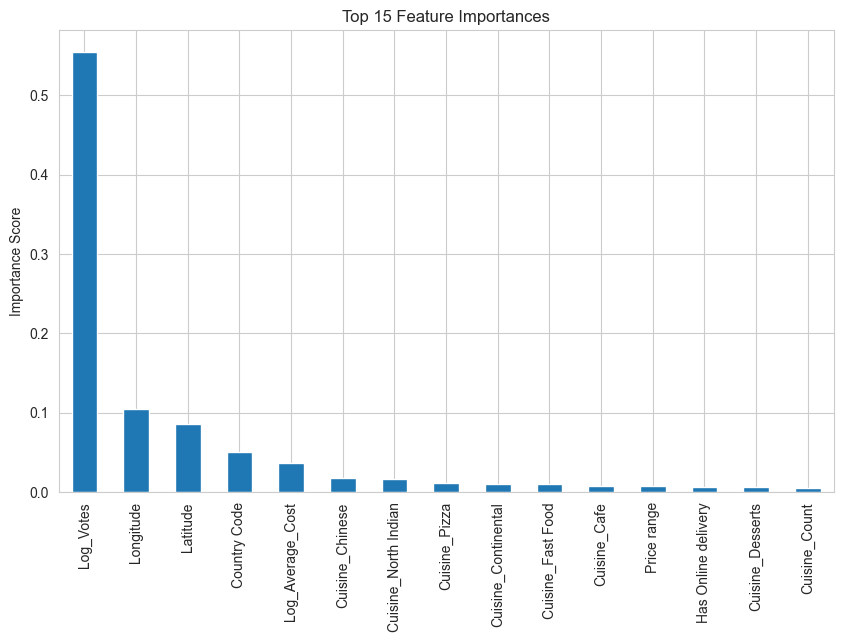

In [70]:
# ==========================================================
# 15. Feature Importance
# ==========================================================

feature_importance = pd.Series(
    best_gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(15).plot(kind="bar")
plt.title("Top 15 Feature Importances")
plt.ylabel("Importance Score")
plt.show()

In [71]:
# ==========================================================
# 16. Save Model
# ==========================================================

MODEL_PATH = PROJECT_ROOT / "Model" / "restaurant_rating_model.pkl"
MODEL_PATH.parent.mkdir(exist_ok=True)

joblib.dump(best_gb, MODEL_PATH)

print("Model saved successfully.")

Model saved successfully.


In [72]:
# Save feature columns
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, PROJECT_ROOT / "Model" / "feature_columns.pkl")
print("Feature columns saved.")

Feature columns saved.


In [74]:
df.to_csv(FINAL_PATH, index=False)